**Data Visualization Aesthetics & Usability Analysis**

This project replicates and extends the empirical research The effect of aesthetic on the usability of data visualization by Nick Cawthon & Andrew Vande Moere. We analyze 11 hierarchical data visualization techniques across multiple usability metrics: task accuracy, response time, error latency, individual/group aesthetic scores, task abandonment rate, and user patience duration.

We explore the correlation between visual aesthetics and practical usability, verifying the core conclusion: aesthetic perception significantly impacts user task performance, patience and task abandonment behavior in data visualization.

**Project Metadata**

《Aesthetic Influence on Usability of Hierarchical Data Visualization》 

This project takes Aesthetic Influence on Usability of Hierarchical Data Visualization as the research theme. Based on the experimental data of the classic paper The effect of aesthetic on the usability of data visualization, it selects 11 typical hierarchical data visualization technologies as research objects. With Python as the technical tool, we quantitatively analyze multiple usability indicators such as task accuracy, response latency and task abandonment rate, combined with individual and group aesthetic evaluation scores. The research aims to reveal the internal connection between visual aesthetic perception and the actual usability of data visualization, and verify the positive impact of interface aesthetics on user task efficiency and persistence.


**Metrics Analyzed:**

Retrieval task accuracy rate

Correct response time & error response latency

Individual & group aesthetic evaluation scores

Correlation between aesthetic score and task abandonment rate

User patience duration before task abandonment

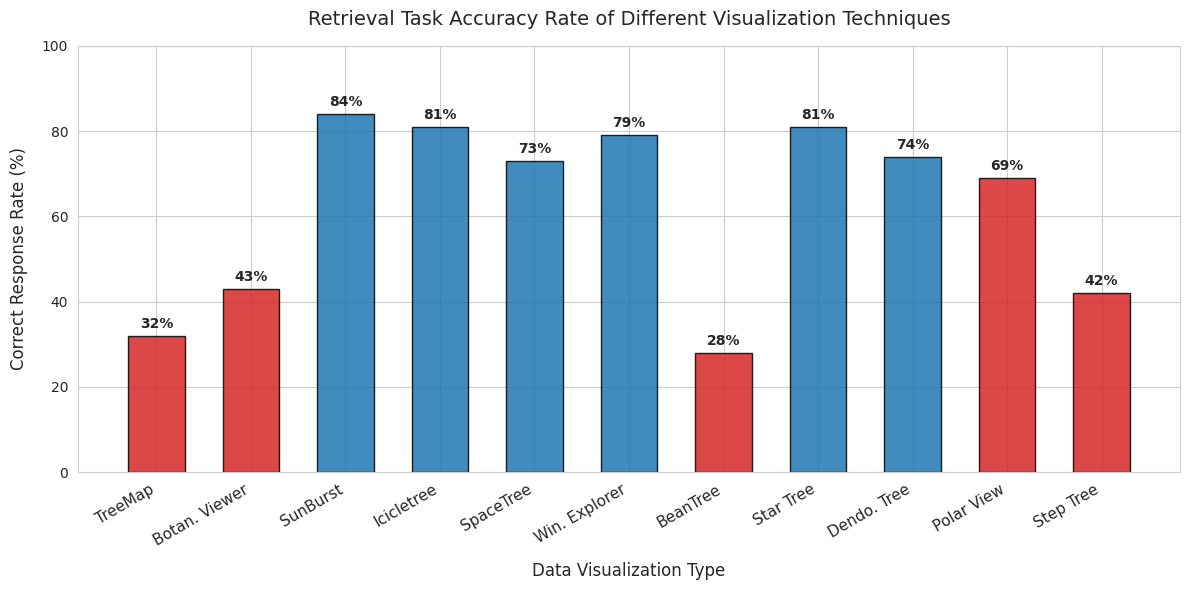

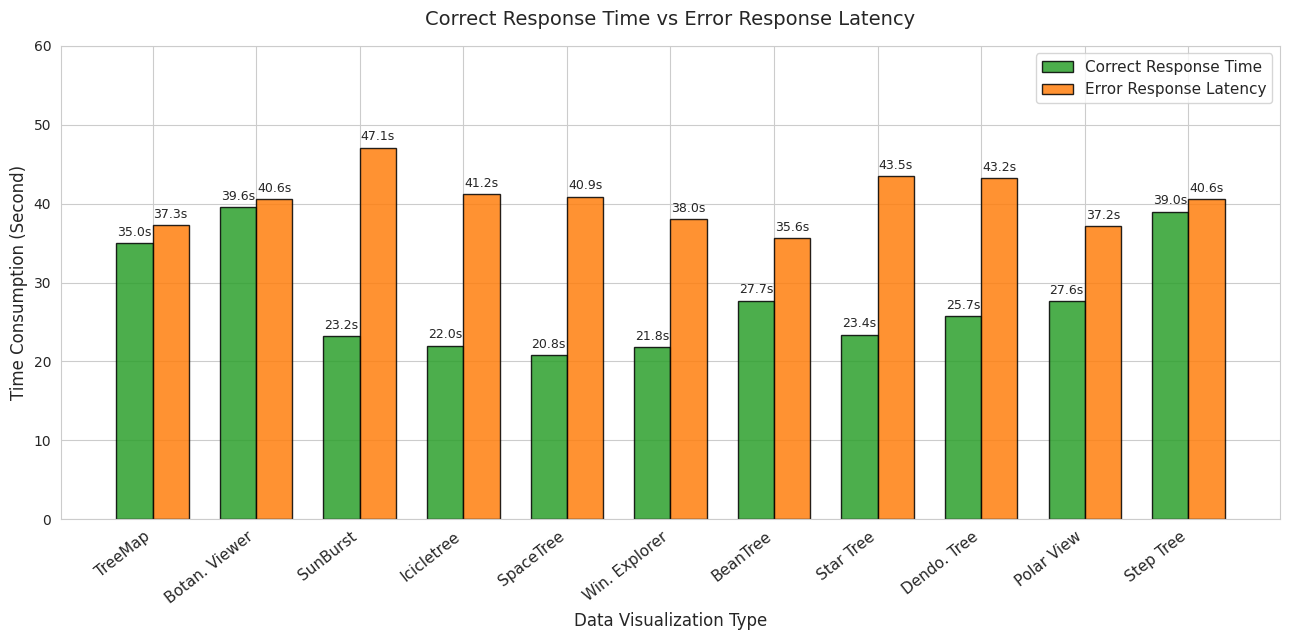

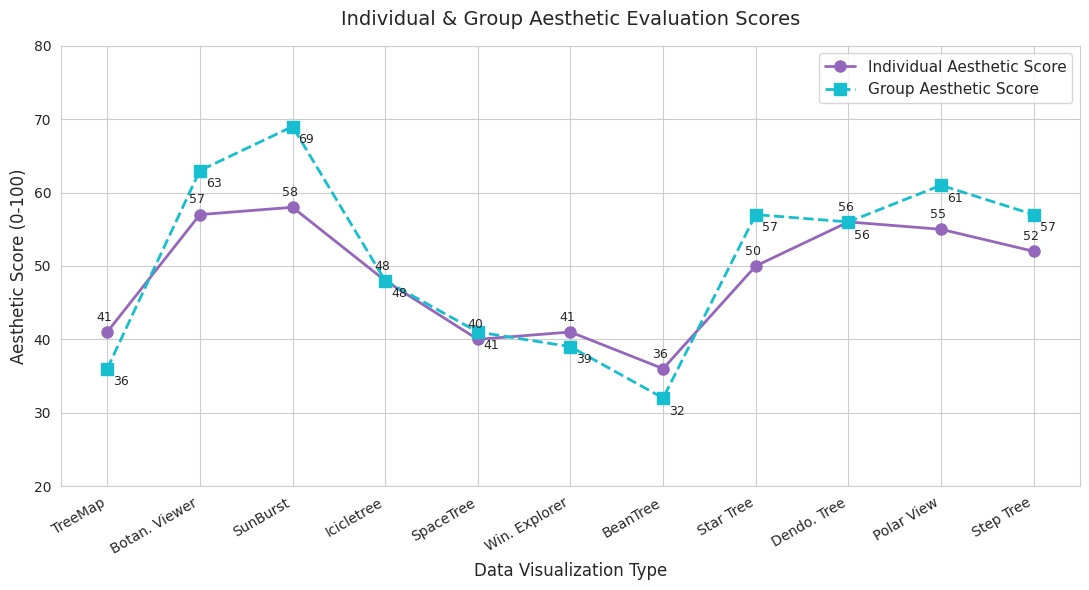

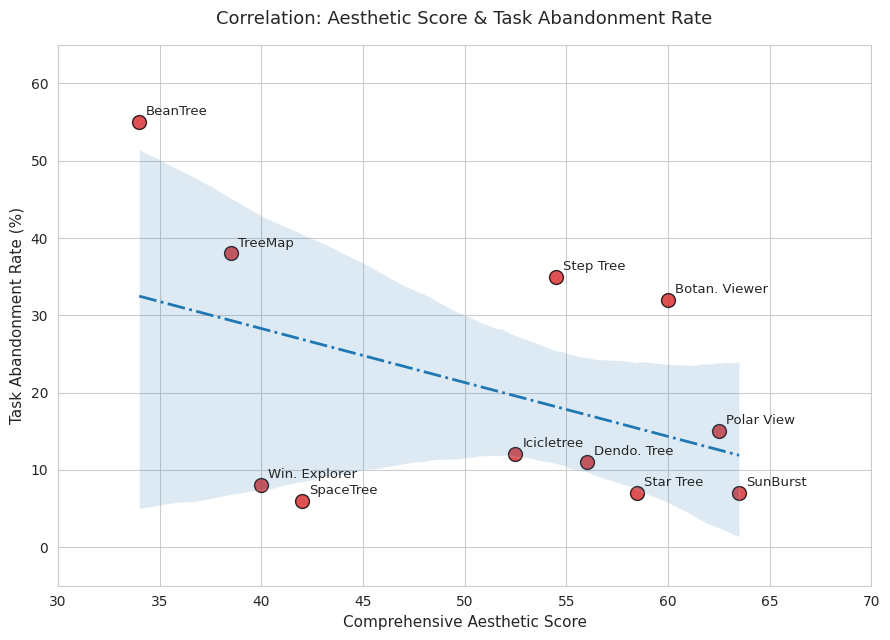

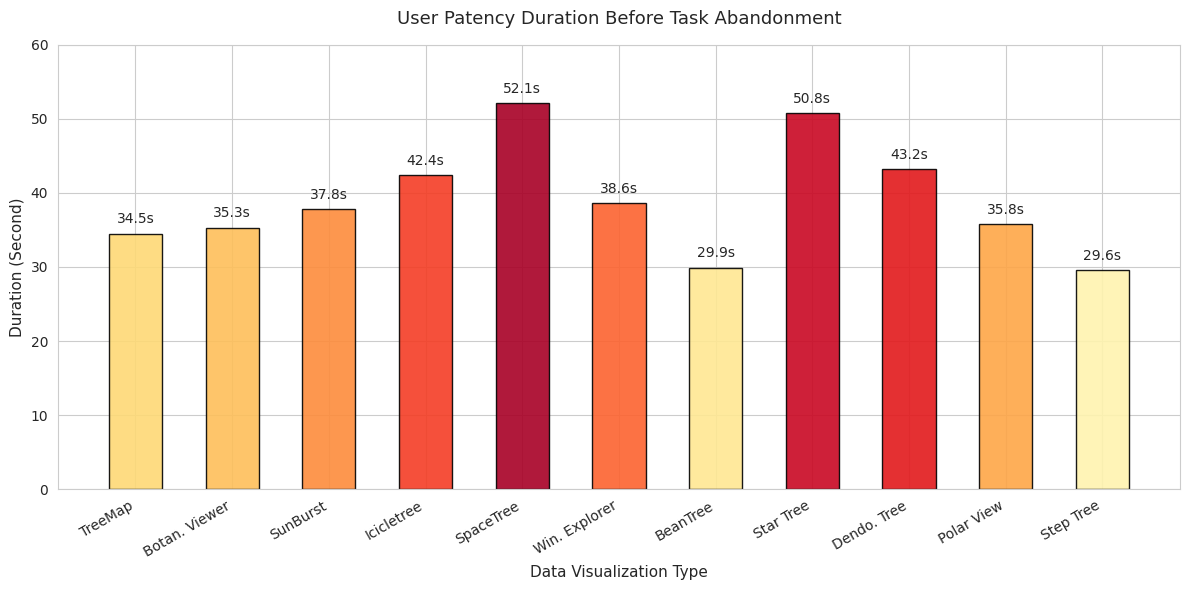

Dataset saved successfully!
  Visualization_Type  Accuracy_Rate(%)  Correct_Response_Time(s)  \
0            TreeMap                32                      35.0   
1      Botan. Viewer                43                      39.6   
2           SunBurst                84                      23.2   
3         Icicletree                81                      22.0   
4          SpaceTree                73                      20.8   

   Error_Latency(s)  Individual_Aesthetic  Group_Aesthetic  \
0              37.3                    41               36   
1              40.6                    57               63   
2              47.1                    58               69   
3              41.2                    48               48   
4              40.9                    40               41   

   Comprehensive_Aesthetic  Abandon_Rate(%)  Abandon_Duration(s)  
0                     38.5               38                 34.5  
1                     60.0               32             

In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Global style & font configuration
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# Define save path
save_path = "./"


# 11 types of hierarchical data visualization techniques
vis_types = [
    'TreeMap', 'Botan. Viewer', 'SunBurst', 'Icicletree', 'SpaceTree',
    'Win. Explorer', 'BeanTree', 'Star Tree', 'Dendo. Tree', 'Polar View', 'Step Tree'
]

# 1. Retrieval Task Accuracy Rate (%)
correct_rates = [32, 43, 84, 81, 73, 79, 28, 81, 74, 69, 42]

# 2. Correct Response Time (s) & Error Response Latency (s)
response_time = [35.0, 39.6, 23.2, 22.0, 20.8, 21.8, 27.7, 23.4, 25.7, 27.6, 39.0]
error_time = [37.3, 40.6, 47.1, 41.2, 40.9, 38.0, 35.6, 43.5, 43.2, 37.2, 40.6]

# 3. Individual Aesthetic Score & Group Aesthetic Score (0-100)
individual_aesthetic = [41, 57, 58, 48, 40, 41, 36, 50, 56, 55, 52]
group_aesthetic = [36, 63, 69, 48, 41, 39, 32, 57, 56, 61, 57]

# 4. Comprehensive Aesthetic Score & Task Abandonment Rate (%)
aesthetics_score = [38.5, 60.0, 63.5, 52.5, 42.0, 40.0, 34.0, 58.5, 56.0, 62.5, 54.5]
abandon_rate = [38, 32, 7, 12, 6, 8, 55, 7, 11, 15, 35]

# 5. User Patency Duration before Abandonment (s)
abandon_latency = [34.5, 35.3, 37.8, 42.4, 52.1, 38.6, 29.9, 50.8, 43.2, 35.8, 29.6]

# Build DataFrame for correlation analysis
df = pd.DataFrame({
    'Visualization': vis_types,
    'Aesthetics': aesthetics_score,
    'Abandon_Rate': abandon_rate
})

# Supplementary

full_data = pd.DataFrame({
    'Visualization_Type': vis_types,
    'Accuracy_Rate(%)': correct_rates,
    'Correct_Response_Time(s)': response_time,
    'Error_Latency(s)': error_time,
    'Individual_Aesthetic': individual_aesthetic,
    'Group_Aesthetic': group_aesthetic,
    'Comprehensive_Aesthetic': aesthetics_score,
    'Abandon_Rate(%)': abandon_rate,
    'Abandon_Duration(s)': abandon_latency
})
full_data.to_csv(save_path + "Visualization_Usability_Dataset.csv", index=False, encoding="utf-8")


# Figure 1: Retrieval Task Accuracy Rate (Bar Chart)

plt.figure(figsize=(12, 6))
# Color rule: Blue for accuracy >=70%, Red for accuracy <70%
colors = ['#1f77b4' if x >= 70 else '#d62728' for x in correct_rates]
bars = plt.bar(vis_types, correct_rates, color=colors, alpha=0.85, edgecolor='black', width=0.6)

# Add value labels
for bar in bars:
    y_val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y_val + 1.2, f"{y_val}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Retrieval Task Accuracy Rate of Different Visualization Techniques", fontsize=14, pad=15)
plt.xlabel("Data Visualization Type", fontsize=12, labelpad=10)
plt.ylabel("Correct Response Rate (%)", fontsize=12, labelpad=10)
plt.ylim(0, 100)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.tight_layout()
plt.savefig(save_path + "Fig1_Accuracy_Rate.png", dpi=300, bbox_inches="tight")
plt.show()


# Figure 2: Correct Response Time & Error Response Latency (Grouped Bar Chart)

x = np.arange(len(vis_types))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 6.5))

bar1 = ax.bar(x - width/2, response_time, width, label='Correct Response Time',
              color='#2ca02c', alpha=0.85, edgecolor='black')
bar2 = ax.bar(x + width/2, error_time, width, label='Error Response Latency',
              color='#ff7f0e', alpha=0.85, edgecolor='black')

# Auto label function
def add_label(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}s', xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

add_label(bar1)
add_label(bar2)

ax.set_title("Correct Response Time vs Error Response Latency", fontsize=14, pad=15)
ax.set_xlabel("Data Visualization Type", fontsize=12)
ax.set_ylabel("Time Consumption (Second)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(vis_types, rotation=38, ha='right', fontsize=11)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 60)
fig.tight_layout()
plt.savefig(save_path + "Fig2_Response_Time.png", dpi=300, bbox_inches="tight")
plt.show()


# Figure 3: Individual & Group Aesthetic Scores (Dual Line Chart)

plt.figure(figsize=(11, 6))
# Individual aesthetic score (solid line + circle marker)
plt.plot(vis_types, individual_aesthetic, marker='o', linewidth=2, markersize=8,
         label='Individual Aesthetic Score', color='#9467bd')
# Group aesthetic score (dashed line + square marker)
plt.plot(vis_types, group_aesthetic, marker='s', linewidth=2, markersize=8, linestyle='--',
         label='Group Aesthetic Score', color='#17becf')

# Add data labels
for idx in range(len(vis_types)):
    plt.annotate(str(individual_aesthetic[idx]), (vis_types[idx], individual_aesthetic[idx]),
                 xytext=(-2, 8), textcoords="offset points", ha='center', fontsize=9)
    plt.annotate(str(group_aesthetic[idx]), (vis_types[idx], group_aesthetic[idx]),
                 xytext=(10, -12), textcoords="offset points", ha='center', fontsize=9)

plt.title("Individual & Group Aesthetic Evaluation Scores", fontsize=14, pad=15)
plt.xlabel("Data Visualization Type", fontsize=12)
plt.ylabel("Aesthetic Score (0-100)", fontsize=12)
plt.ylim(20, 80)
plt.xticks(rotation=30, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(save_path + "Fig3_Aesthetic_Score.png", dpi=300, bbox_inches="tight")
plt.show()


# Figure 4: Correlation between Aesthetic Score & Task Abandonment Rate (Regression Scatter Plot)

plt.figure(figsize=(9, 6.5))
sns.regplot(x='Aesthetics', y='Abandon_Rate', data=df,
            scatter_kws={"s": 100, "color": "#d62728", "alpha": 0.8, "edgecolor": "black"},
            line_kws={"color": "#1f77b4", "linewidth": 2, "linestyle": "-."})

# Label each visualization type
for i, name in enumerate(vis_types):
    plt.annotate(name, (df['Aesthetics'][i], df['Abandon_Rate'][i]),
                 xytext=(5, 5), textcoords="offset points", fontsize=9.5)

plt.title("Correlation: Aesthetic Score & Task Abandonment Rate", fontsize=13, pad=15)
plt.xlabel("Comprehensive Aesthetic Score", fontsize=11)
plt.ylabel("Task Abandonment Rate (%)", fontsize=11)
plt.xlim(30, 70)
plt.ylim(-5, 65)
plt.tight_layout()
plt.savefig(save_path + "Fig4_Abandon_Correlation.png", dpi=300, bbox_inches="tight")
plt.show()


# Figure 5: User Patency Duration before Task Abandonment (Gradient Bar Chart)

plt.figure(figsize=(12, 6))
# Gradient color mapping based on duration
color_palette = sns.color_palette("YlOrRd", len(abandon_latency))
rank_idx = np.argsort(abandon_latency)
bar_colors = [color_palette[list(rank_idx).index(i)] for i in range(len(abandon_latency))]

bars = plt.bar(vis_types, abandon_latency, color=bar_colors, alpha=0.9, edgecolor='black', width=0.55)

# Add value labels
for bar in bars:
    y_val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y_val + 1.0, f"{y_val}s",
             ha='center', va='bottom', fontsize=10)

plt.title("User Patency Duration Before Task Abandonment", fontsize=13, pad=15)
plt.xlabel("Data Visualization Type", fontsize=11)
plt.ylabel("Duration (Second)", fontsize=11)
plt.ylim(0, 60)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(save_path + "Fig5_Patency_Duration.png", dpi=300, bbox_inches="tight")
plt.show()

print("Dataset saved successfully!")
print(full_data.head())